# ディリクレ多項分布によるブランド選択行動の分析

ディリクレ多項分布モデルを用いて、SOFT DRINKS カテゴリのブランド選択行動を定量化する。集中度パラメータ $S$ がブランドロイヤルティを表す単一の数値として機能し、スイッチング行列によってブランド間の遷移確率が把握できる。

## Step 1: データ取得・前処理

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln
from scipy.optimize import minimize

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Hiragino Sans"

### 1.1 データ読み込み

In [3]:
DATA_DIR = "../data/dunnhumby"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    os.system("kaggle datasets download frtgnn/dunnhumby-the-complete-journey -p ../data/dunnhumby --unzip")

df_trans = pd.read_csv(os.path.join(DATA_DIR, "transaction_data.csv"))
df_product = pd.read_csv(os.path.join(DATA_DIR, "product.csv"))

### 1.2 SOFT DRINKS フィルタリング・ブランド集約

`negative_binomial.ipynb` と同じ条件: SOFT DRINKS カテゴリ、最初の52週間（DAY 1〜364）、MANUFACTURER コード上位5 + Others の6ブランドグループ。

In [4]:
soft_drink_ids = df_product.loc[
    df_product["COMMODITY_DESC"] == "SOFT DRINKS", "PRODUCT_ID"
].unique()

df_sd = df_trans[df_trans["PRODUCT_ID"].isin(soft_drink_ids)].copy()
df_sd = df_sd.merge(
    df_product[["PRODUCT_ID", "BRAND", "MANUFACTURER"]],
    on="PRODUCT_ID",
    how="left",
)

min_day = df_sd["DAY"].min()
df_sd = df_sd[df_sd["DAY"] <= min_day + 7 * 52 - 1].copy()

In [5]:
mfr_counts = df_sd["MANUFACTURER"].value_counts()
top5_mfr = mfr_counts.head(5).index.tolist()

df_sd["brand_group"] = df_sd["MANUFACTURER"].astype(str).where(
    df_sd["MANUFACTURER"].isin(top5_mfr), other="Others"
)
mfr_labels = {str(m): f"Mfr_{m}" for m in top5_mfr}
mfr_labels["Others"] = "Others"
df_sd["brand_group"] = df_sd["brand_group"].map(mfr_labels)

In [11]:
df_hh_brand = (
    df_sd.groupby(["household_key", "brand_group", "BASKET_ID"])
    .size()
    .reset_index(name="items")
    .groupby(["household_key", "brand_group"])
    .size()
    .reset_index(name="occasions")
)

df_hh_brand_wide = df_hh_brand.pivot(
    index="household_key", columns="brand_group", values="occasions"
).fillna(0).astype(int)

brand_cols = sorted(df_hh_brand_wide.columns.tolist())
X = df_hh_brand_wide[brand_cols].values  # shape: (N, J)
n = X.sum(axis=1)                         # purchase occasions per household
N, J = X.shape

print(f"世帯数: {N}, ブランド数: {J}")
print(f"平均購買機会数: {n.mean():.1f}")

世帯数: 2272, ブランド数: 6
平均購買機会数: 18.7


In [13]:
df_hh_brand_wide

brand_group,Mfr_103,Mfr_1208,Mfr_2,Mfr_2224,Mfr_69,Others
household_key,,,,,,
1,9,2,1,1,1,0
2,8,10,0,2,1,0
3,16,12,0,3,1,1
4,0,2,3,0,0,0
6,2,17,0,0,4,0
...,...,...,...,...,...,...
2496,0,7,0,0,0,0
2497,28,8,2,3,20,0
2498,0,7,0,1,1,0


## Step 2: ディリクレ多項分布モデル

### モデルの導出

カテゴリの購入回数 $n_i$ が与えられたとき、消費者 $i$ が各ブランド $j = 1, \ldots, J$ を選択する回数 $\mathbf{x}_i = (x_{i1}, \ldots, x_{iJ})$ をモデリングする。

**仮定1（個人レベル）**: 各消費者はブランド選択確率ベクトル $\boldsymbol{\theta}_i$ を持ち、各購買機会で独立にブランドを選択する。

$$
\mathbf{x}_i \mid \boldsymbol{\theta}_i, n_i \sim \mathrm{Multinomial}(n_i, \boldsymbol{\theta}_i)
$$

**仮定2（集団レベル）**: 消費者間のブランド選好の異質性をディリクレ分布で表現する。

$$
\boldsymbol{\theta}_i \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}), \qquad \boldsymbol{\alpha} = (\alpha_1, \ldots, \alpha_J)
$$

**導出**: $\boldsymbol{\theta}$ を積分消去すると、ディリクレ多項分布が得られる。

$$
P(\mathbf{x}_i \mid n_i, \boldsymbol{\alpha}) = \binom{n_i}{\mathbf{x}_i} \frac{B(\mathbf{x}_i + \boldsymbol{\alpha})}{B(\boldsymbol{\alpha})}
$$

### パラメータの意味

| パラメータ | 意味 |
|-----------|------|
| $\alpha_j$ | ブランド $j$ への選好の強さ |
| $S = \sum_j \alpha_j$ | **集中度パラメータ**: 大きいほどブランドロイヤルティが高い（スイッチングが少ない） |
| $\alpha_j / S$ | ブランド $j$ の期待市場シェア |

### 2.1 MLE によるパラメータ推定

In [7]:
def dm_neg_loglik(log_alpha, X, n):
    """Negative log-likelihood of Dirichlet-Multinomial distribution."""
    alpha = np.exp(log_alpha)
    S = alpha.sum()
    N = len(n)
    ll = N * gammaln(S) - gammaln(n + S).sum()
    ll += (gammaln(X + alpha) - gammaln(alpha)).sum()
    return -ll

share_init = X.sum(axis=0) / X.sum()
alpha_init = share_init * J

result_dm = minimize(
    dm_neg_loglik,
    x0=np.log(alpha_init),
    args=(X, n),
    method="Nelder-Mead",
    options={"maxiter": 50000, "xatol": 1e-8, "fatol": 1e-8},
)

alpha_hat = np.exp(result_dm.x)
S_hat = alpha_hat.sum()

print(f"収束: {result_dm.success}")
print(f"S = {S_hat:.4f}")
for j, col in enumerate(brand_cols):
    print(f"  α_{col}: {alpha_hat[j]:.4f}  (シェア: {alpha_hat[j]/S_hat:.1%})")

収束: True
S = 4.1345
  α_Mfr_103: 1.2099  (シェア: 29.3%)
  α_Mfr_1208: 1.1601  (シェア: 28.1%)
  α_Mfr_2: 0.1059  (シェア: 2.6%)
  α_Mfr_2224: 0.8068  (シェア: 19.5%)
  α_Mfr_69: 0.5242  (シェア: 12.7%)
  α_Others: 0.3276  (シェア: 7.9%)


In [10]:
alpha_init, alpha_hat, S_hat

(array([1.88995912, 1.60395621, 0.0847155 , 1.00093972, 1.06662595,
        0.35380351]),
 array([1.20994728, 1.16007927, 0.10592256, 0.80677842, 0.52418333,
        0.32759056]),
 np.float64(4.134501421120749))

### 2.2 ブランドシェア: 実測 vs モデル

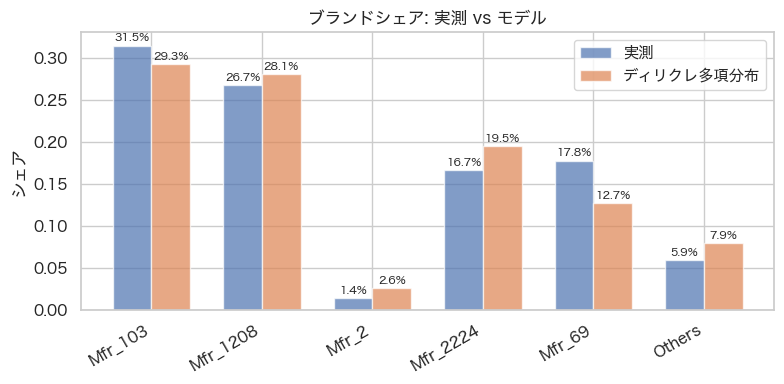

In [9]:
observed_share = X.sum(axis=0) / X.sum()
model_share = alpha_hat / S_hat

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(J)
bar_width = 0.35
ax.bar(x_pos - bar_width / 2, observed_share, bar_width, label="実測", alpha=0.7)
ax.bar(x_pos + bar_width / 2, model_share, bar_width, label="ディリクレ多項分布", alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(brand_cols, rotation=30, ha="right")
ax.set_ylabel("シェア")
ax.set_title("ブランドシェア: 実測 vs モデル")
ax.legend()
for i, (o, m) in enumerate(zip(observed_share, model_share)):
    ax.text(i - bar_width / 2, o + 0.005, f"{o:.1%}", ha="center", fontsize=8)
    ax.text(i + bar_width / 2, m + 0.005, f"{m:.1%}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Step 3: ブランドロイヤルティの定量化

ディリクレ多項分布のポリアの壺（Pólya urn）的な性質から、直前の購買がブランド $j$ であったとき、次の購買でも $j$ を選ぶ確率（繰り返し購買確率）は

$$
P(\text{次} = j \mid \text{前} = j) = \frac{\alpha_j + 1}{S + 1}
$$

**ロイヤルティのリフト**はこの繰り返し購買確率をシェア $\alpha_j / S$ で割ったもので、ランダムに選んだ場合の何倍の確率で同じブランドを再購買するかを表す。

### 3.1 ロイヤルティのリフト

In [14]:
repeat_prob = (alpha_hat + 1) / (S_hat + 1)
loyalty_lift = repeat_prob / model_share

df_loyalty = pd.DataFrame({
    "Brand": brand_cols,
    "Share (%)": (model_share * 100).round(1),
    "Repeat Prob (%)": (repeat_prob * 100).round(1),
    "Loyalty Lift": loyalty_lift.round(2),
}).sort_values("Share (%)", ascending=False).reset_index(drop=True)

df_loyalty

,Brand,Share (%),Repeat Prob (%),Loyalty Lift
0,Mfr_103,29.3,43.0,1.47
1,Mfr_1208,28.1,42.1,1.50
2,Mfr_2224,19.5,35.2,1.80
3,Mfr_69,12.7,29.7,2.34
4,Others,7.9,25.9,3.26
5,Mfr_2,2.6,21.5,8.41


### 3.2 スイッチング行列

要素 $(j, k)$ は「前回ブランド $j$ を購買した消費者が次回ブランド $k$ を選ぶ確率」を表す。

$$
P(\text{次} = k \mid \text{前} = j) = \begin{cases} \dfrac{\alpha_j + 1}{S + 1} & (k = j) \\[6pt] \dfrac{\alpha_k}{S + 1} & (k \neq j) \end{cases}
$$

どのブランドからのスイッチングであっても、流入先は市場シェアに比例する（ディリクレ分布の exchangeability）。

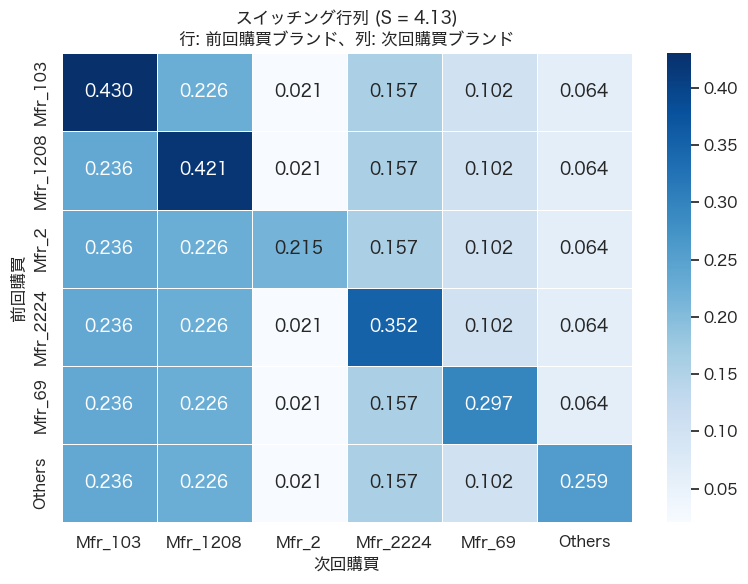

In [9]:
switch_matrix = np.tile(alpha_hat / (S_hat + 1), (J, 1))  # off-diagonal: alpha_k / (S+1)
np.fill_diagonal(switch_matrix, (alpha_hat + 1) / (S_hat + 1))  # diagonal: (alpha_j+1)/(S+1)

df_switch = pd.DataFrame(switch_matrix, index=brand_cols, columns=brand_cols)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_switch,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_title(f"スイッチング行列 (S = {S_hat:.2f})\n行: 前回購買ブランド、列: 次回購買ブランド")
ax.set_ylabel("前回購買")
ax.set_xlabel("次回購買")
plt.tight_layout()
plt.show()

In [10]:
df_switch.round(3)

,Mfr_103,Mfr_1208,Mfr_2,Mfr_2224,Mfr_69,Others
Mfr_103,0.430,0.226,0.021,0.157,0.102,0.064
Mfr_1208,0.236,0.421,0.021,0.157,0.102,0.064
Mfr_2,0.236,0.226,0.215,0.157,0.102,0.064
Mfr_2224,0.236,0.226,0.021,0.352,0.102,0.064
Mfr_69,0.236,0.226,0.021,0.157,0.297,0.064
Others,0.236,0.226,0.021,0.157,0.102,0.259
